In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Dataset analysis

In [2]:
titanic = pd.read_csv("../data/titanic.csv")
# titanic.info()
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- age, cabin and embarked have null values
- name, sex, ticket, cabin, embarked must be converted to numbers

# Train test split

In [3]:
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data cleaning

In [8]:
num_attribs = list(X_train.select_dtypes(include=["int64", "float64"]).columns)
cat_attribs = list(X_train.select_dtypes(include=["object", "category", "bool"]).columns)


num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Model

Accuracy: 0.8212290502793296

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion matrix:



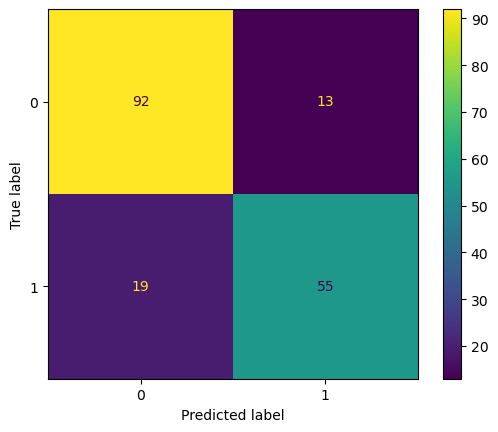

In [9]:
log_reg = make_pipeline(
    preprocessing,
    LogisticRegression()
)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print()

